# Market Basket Analysis — 01 EDA

Retail transactions from the UCI Online Retail dataset. Before mining association rules we look at what sells and how big baskets are.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils
df=utils.load_transactions()
print('transaction rows:',len(df),'| invoices:',df.InvoiceNo.nunique(),'| products:',df.Description.nunique())

transaction rows: 129162 | invoices: 16866 | products: 150


## 1. Best-selling products

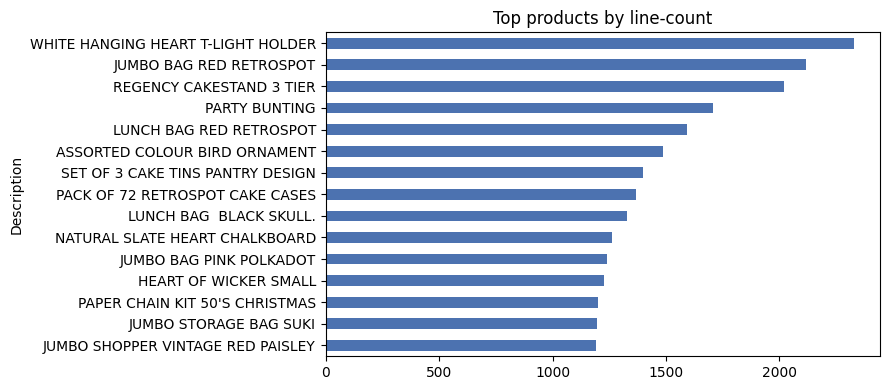

In [2]:
top=df.Description.value_counts().head(15)
fig,ax=plt.subplots(figsize=(9,4)); top.plot(kind='barh',ax=ax,color='#4c72b0'); ax.invert_yaxis(); ax.set_title('Top products by line-count'); plt.tight_layout(); plt.show()

## 2. Basket size distribution

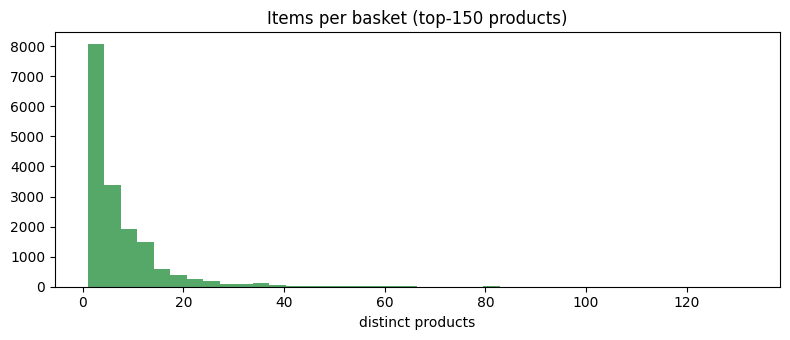

baskets: 16866 | median items/basket: 5


In [3]:
basket=utils.build_basket(df)
sizes=basket.sum(axis=1)
fig,ax=plt.subplots(figsize=(8,3.5)); ax.hist(sizes,bins=40,color='#55a868'); ax.set_title('Items per basket (top-150 products)'); ax.set_xlabel('distinct products'); plt.tight_layout(); plt.show()
print('baskets:',basket.shape[0],'| median items/basket:',int(sizes.median()))

## 3. Summary

- ~16,900 invoices over the top-150 products.
- Most baskets are small (a few distinct items), with a long tail of large orders.
- Notebook 02 runs Apriori to find which products co-occur far more than chance (high lift).